# Customer Churn Prediction

Step 1: imports

In [1]:
# Standard import 
from logging import warning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from collections import Counter


#sklearn 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


#Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#Metric & utilities
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")

#Display Setting
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
display(df.info())
display(df.describe(include='all'). T)

# missing values
print("\nMissing Values per column:")
print("df.isnull().sum")

# Target
print("\nExited Value Counts:")
print(df['Exited'].value_counts())

print("\nExited Proportion:")
print(df['Exited'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0



Missing Values per column:
df.isnull().sum

Exited Value Counts:
Exited
0    7963
1    2037
Name: count, dtype: int64

Exited Proportion:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


# Step 4: Exploratory Data Analysis(visualizations)

We'll look at distribution of numeric features, relationships with churn and categorical features

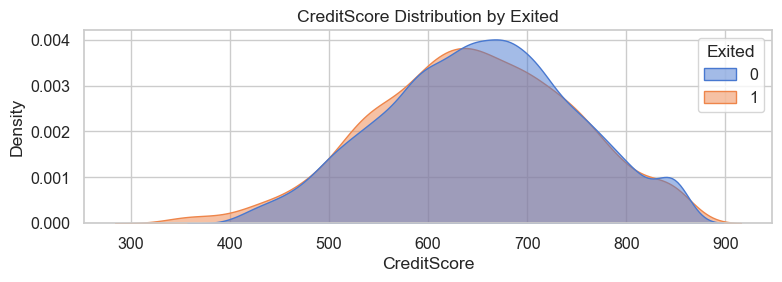

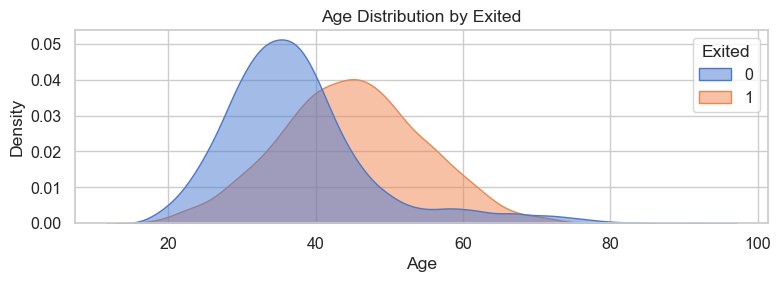

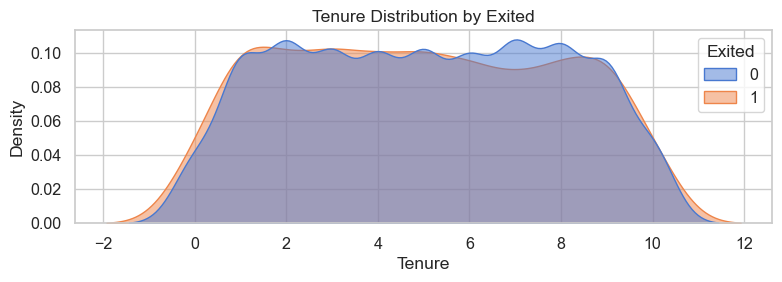

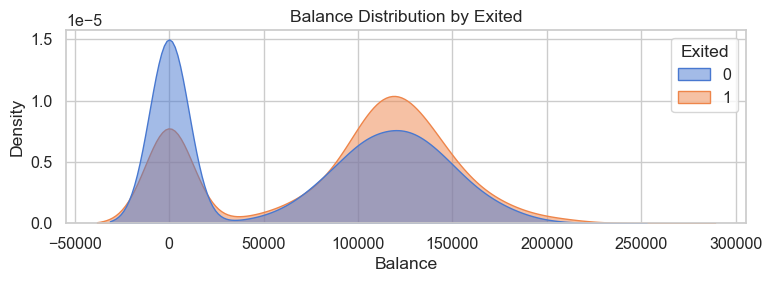

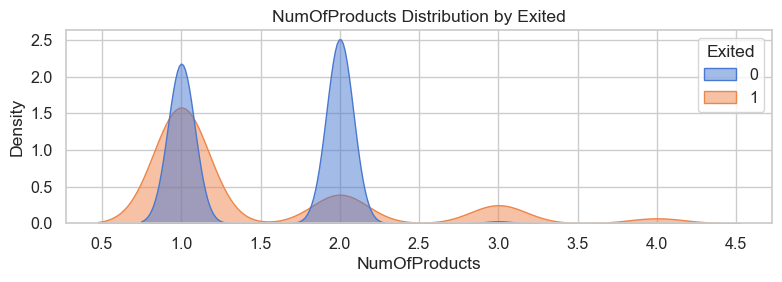

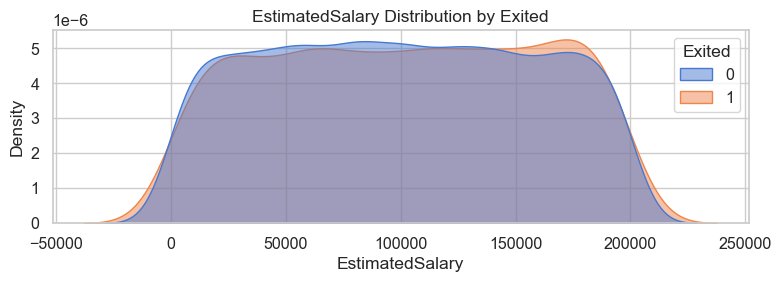

In [8]:
nums_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

for col in nums_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(
        data=df,
        x=col,
        hue='Exited',
        fill=True,
        common_norm=False,
        alpha=0.5
    )
    plt.title(f'{col} Distribution by Exited')
    plt.tight_layout()
    plt.show()

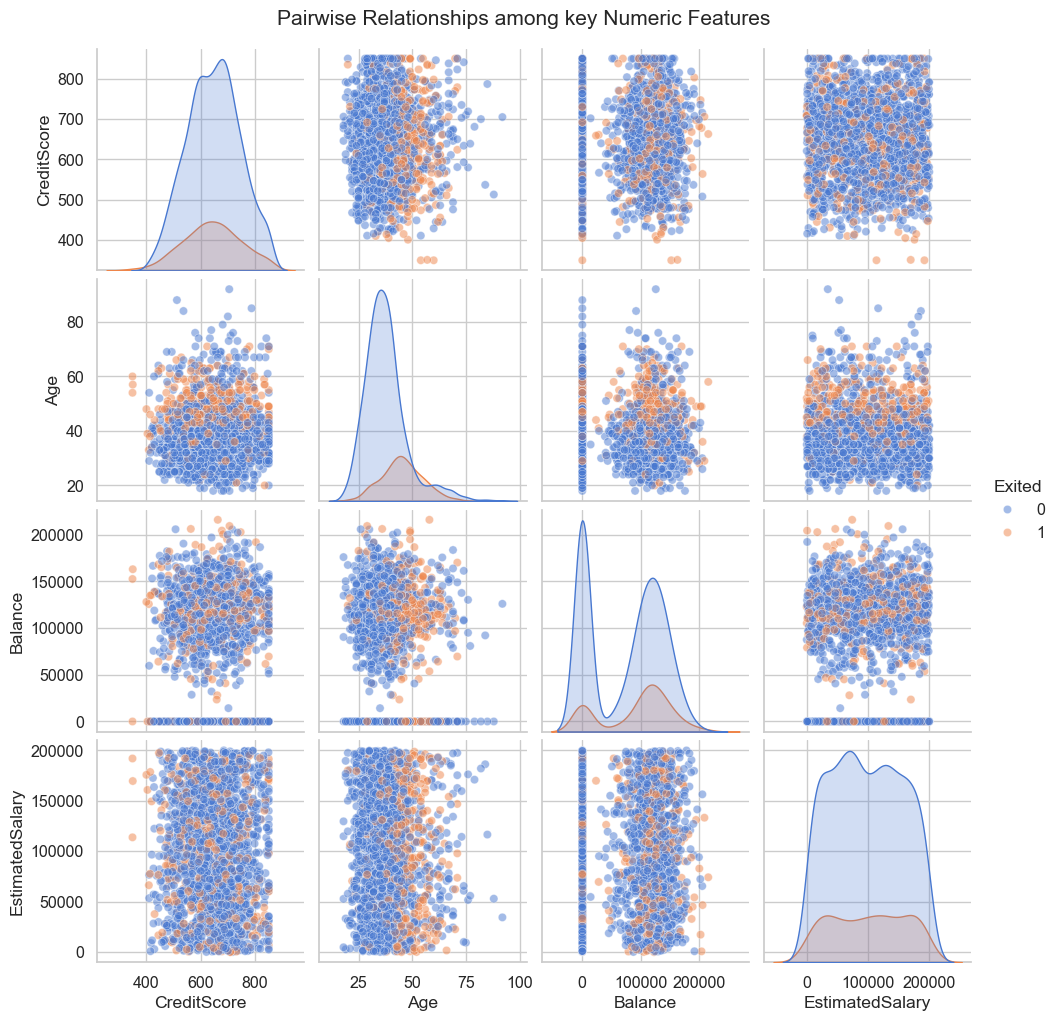

In [11]:
# --- Paorplot (sampled for speed)
from altair import Y


sns.pairplot(df.sample(frac=0.2, random_state=42),
             vars=['CreditScore',
    'Age',
    'Balance',
    'EstimatedSalary'],
    hue='Exited', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships among key Numeric Features', y=1.02)
plt.show()

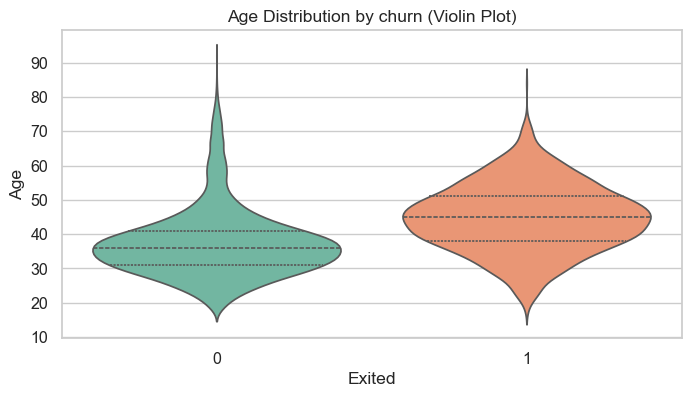

In [14]:
# --- Violin plot for age
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='Exited', y='Age', inner='quart', palette='Set2')
plt.title("Age Distribution by churn (Violin Plot)")
plt.show()

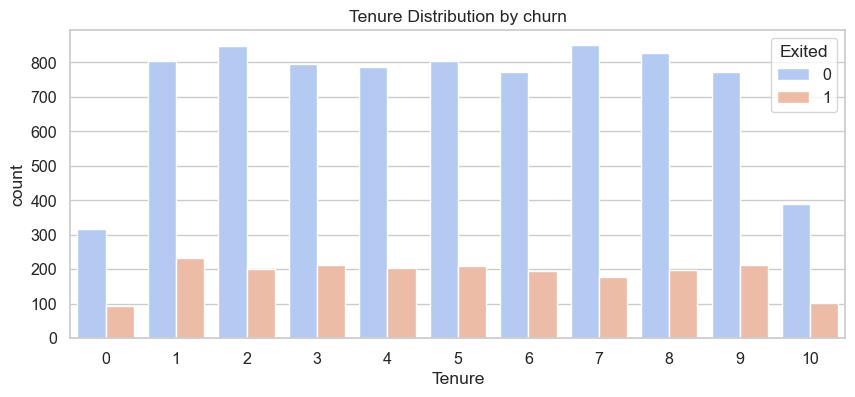

In [16]:
# --- Trnure Distribution 
plt.figure(figsize=(10,4))
sns.countplot(data = df, x='Tenure', hue='Exited', palette='coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()

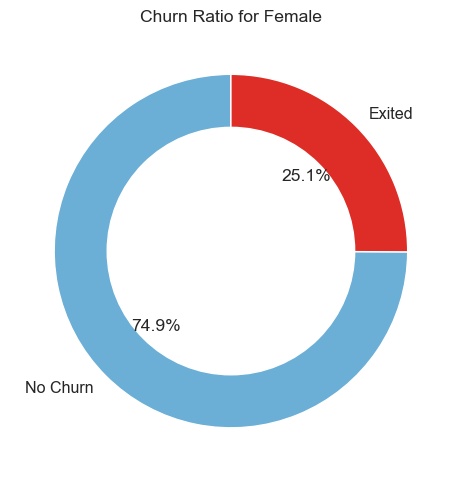

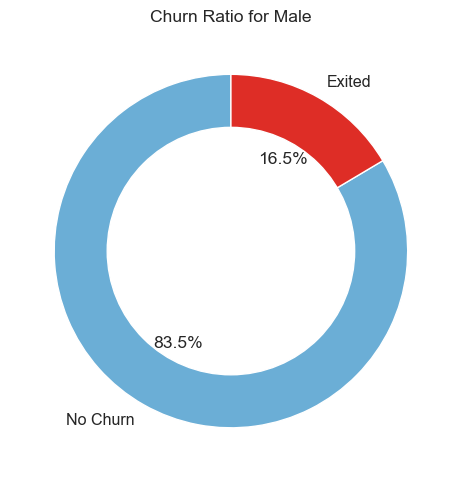

In [19]:
# --- Gender Vs Churn Donut Chart
gender_counts = (
    df.groupby('Gender')['Exited']
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

for gender in gender_counts.index:
    plt.figure(figsize=(5, 5))

    plt.pie(
        gender_counts.loc[gender],
        labels=['No Churn', 'Exited'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#6baed6', '#de2d26']
    )

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    plt.gca().add_artist(centre_circle)

    plt.title(f'Churn Ratio for {gender}')
    plt.tight_layout()
    plt.show()

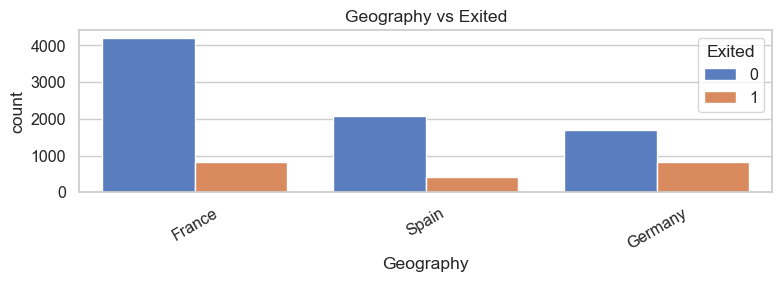

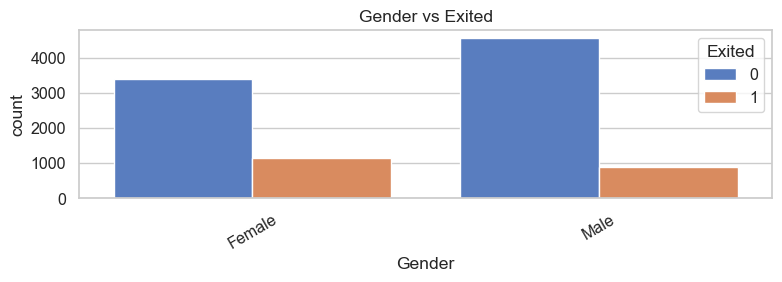

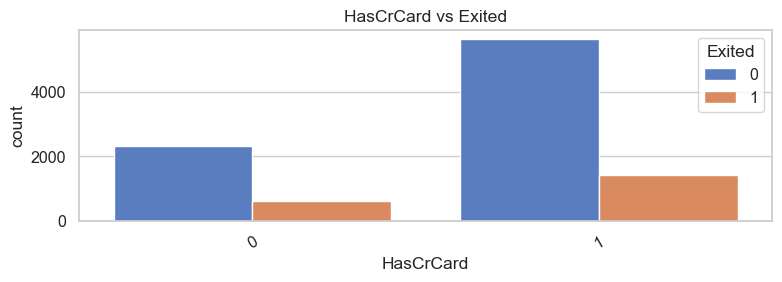

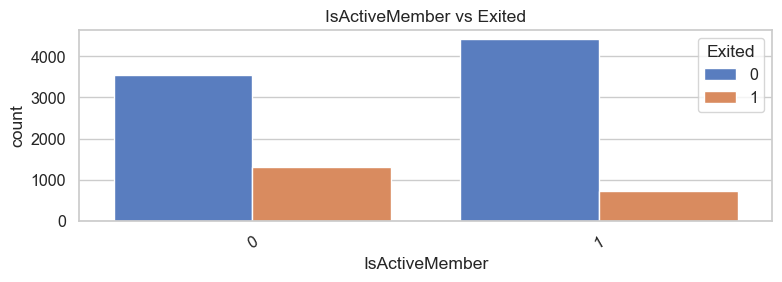

In [24]:
# --- Categorical data
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
for c in cat_cols:
    plt.figure(figsize=(8,3))
    sns.countplot(data=df, x = c, hue = 'Exited')
    plt.title(f'{c} vs Exited')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

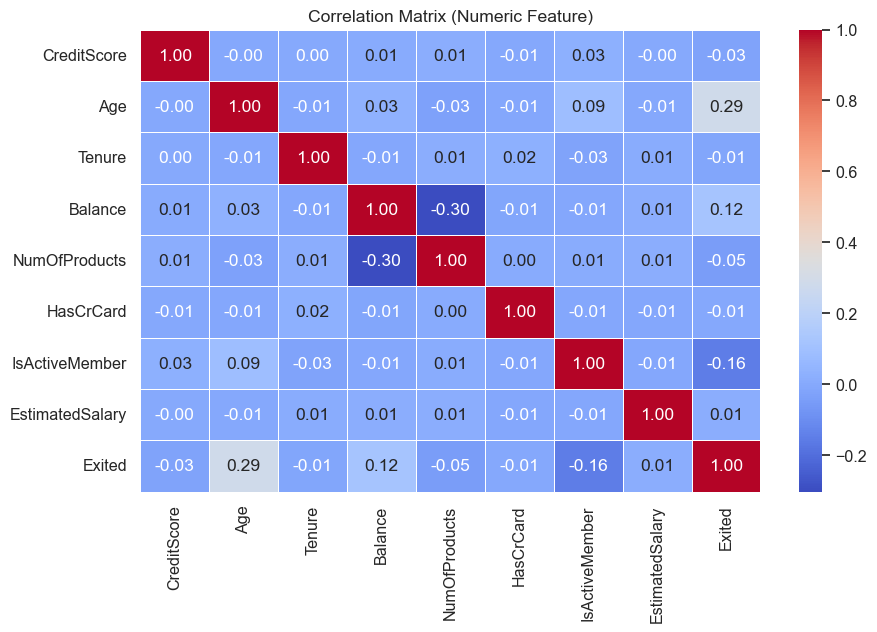

In [28]:
# --- Heatmap Visualization
corr = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt = '.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Numeric Feature)')
plt.show()

In [30]:
# --- Numeric Correlation heatmap 
numeric_data = df[nums_cols]
corr = numeric_data.corr()
corr.style.background_gradient(cmap='coolwarm')

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


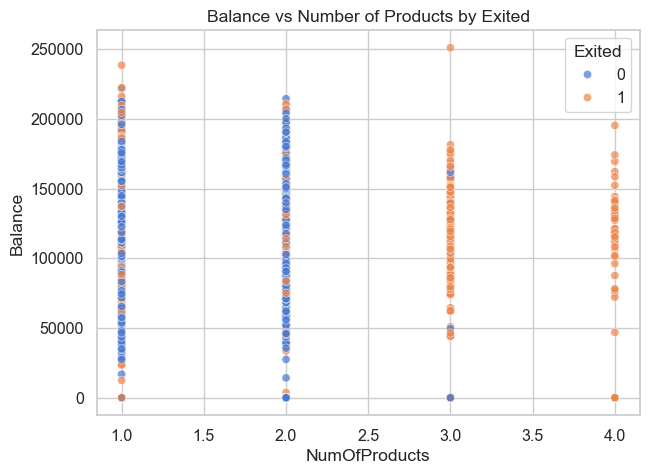

In [32]:
# Balance vs Number of Products
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='NumOfProducts',
    y='Balance',
    hue='Exited',
    alpha=0.7
)

plt.title('Balance vs Number of Products by Exited')
plt.show()

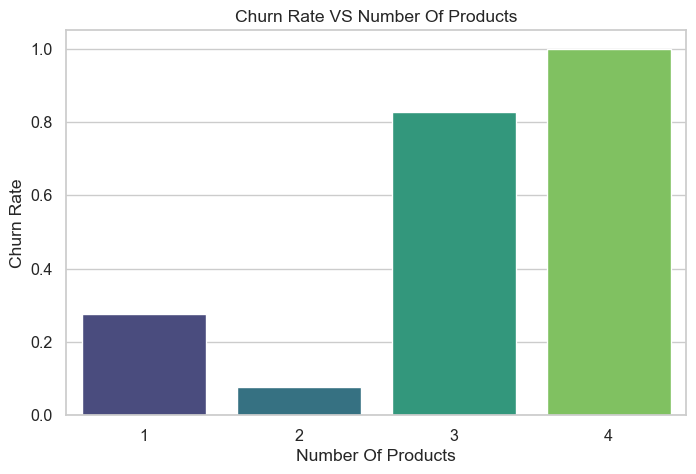

In [35]:
# --- Aggregate churn rate per number of products
churn_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data=churn_rate, x='NumOfProducts', y='Exited', palette='viridis')
plt.xlabel('Number Of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate VS Number Of Products')
plt.show()


# Step 5: Feature Engineering

Create meaningful features: e.g balance per product, age group, salary bracket and handle missing value

In [38]:
# Feature Engineering example
df_fe = df.copy()

# Balance per product
df_fe['balance_per_product'] = df_fe['Balance'] / (df_fe['NumOfProducts'].replace(0, np.nan))
df_fe['balance_per_product'].fillna(0, inplace=True)

#Salary to balance ratio
df_fe['salary_balance_ratio'] = df_fe['EstimatedSalary'] / (df_fe['Balance'].replace(0, np.nan))
df_fe['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(), inplace=True)

# Age group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25','25-34', '35-44', '45-54', '55-64', '65+']
df_fe['age_group'] = pd.cut(df_fe['Age'], bins=bins, labels=labels)

# Tenure Bucket
df_fe['tenure_bucket'] = pd.cut(df_fe['Tenure'], bins=[-1,0,2,5,10,100], labels=['0', '1-2', '3-5', '6-10', '10+'])

# Flag high balance
df_fe['high_balance'] = (
    df_fe['Balance'] > df_fe['Balance'].quantile(0.75)
).astype(int)

# Quick checks
df_fe[['balance_per_product', 'salary_balance_ratio', 'Age', 'age_group', 'Tenure', 'tenure_bucket', 'high_balance']].head()

,balance_per_product,salary_balance_ratio,Age,age_group,Tenure,tenure_bucket,high_balance
0,0.000000,0.839258,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,0.839258,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


# Step 6. Preprocessing - encoding & scaling

We'll build a preprocessing pipeline that encodes categorical features and scales numerical ones.

In [40]:
# Define target
target = 'Exited'

# Columns to drop
drop_cols = ['CustomerId', 'RowNumber', 'Surname']

# Features
features = [c for c in df_fe.columns if c not in [target] + drop_cols]

# Numeric features
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary',
    'balance_per_product',
    'salary_balance_ratio'
]

# Categorical features
categorical_features = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember',
    'age_group',
    'tenure_bucket',
    'high_balance'
]

# Convert categorical columns to object type
df_fe[categorical_features] = df_fe[categorical_features].astype('object')

# Numeric preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'age_group', 'tenure_bucket', 'high_balance']


# Step 7. Train Test split

In [41]:
X = df_fe[features]
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Train churn proportion:', y_train.mean(), 'Test churn proportion:', y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


# Step 8. Train Multiple models with a pipeline and compare using cross-validation

In [42]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    results[name] = scores
    print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.7877 Std=0.0244
RandomForest AUC: Mean=0.8494 Std=0.0131
GradientBoosting AUC: Mean=0.8628 Std=0.0098
AdaBoost AUC: Mean=0.8462 Std=0.0133
SVC AUC: Mean=0.8351 Std=0.0104


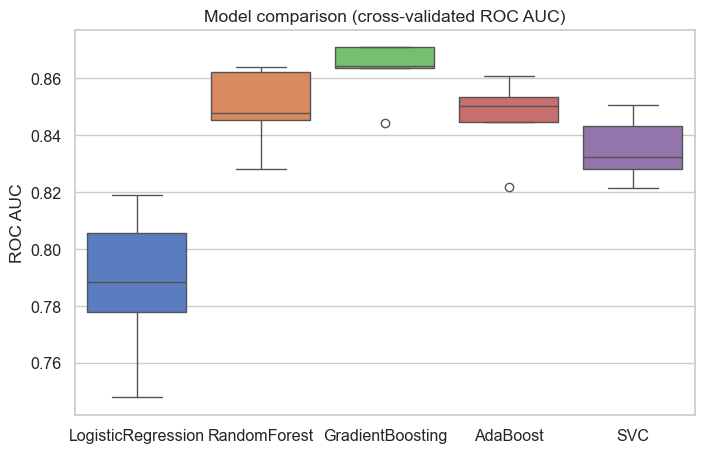

In [43]:
# Boxplot of CV AUC scores
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

# Step 9. Fit best model on full train set and evaluate on test set

In [44]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

('GradientBoosting', 0.8628177037686241)

Test Accuracy: 0.8680
Test Precision: 0.7804
Test Recall: 0.4889
Test F1-score: 0.6012
Test ROC AUC: 0.8693

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



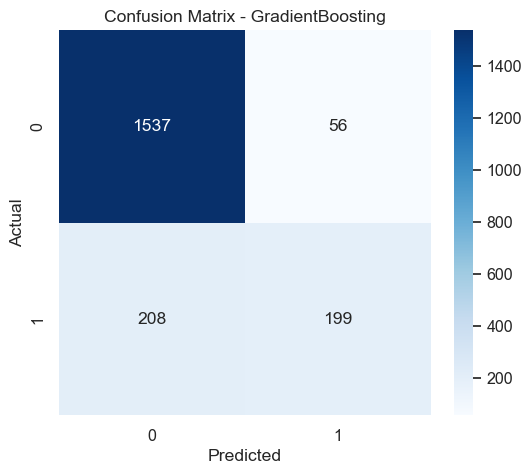

In [45]:
best_model = models[best_name]

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

# Step 10. Feature importance (if applicable)

If the chosen model supports feature importance (RandomForest/GradientBoosting), show top features

,Feature,Importance
1,Age,0.327733
4,NumOfProducts,0.266459
6,balance_per_product,0.067793
16,IsActiveMember_1,0.056384
3,Balance,0.052536
9,Geography_Germany,0.050689
15,IsActiveMember_0,0.044428
7,salary_balance_ratio,0.029792
5,EstimatedSalary,0.025556
0,CreditScore,0.022927


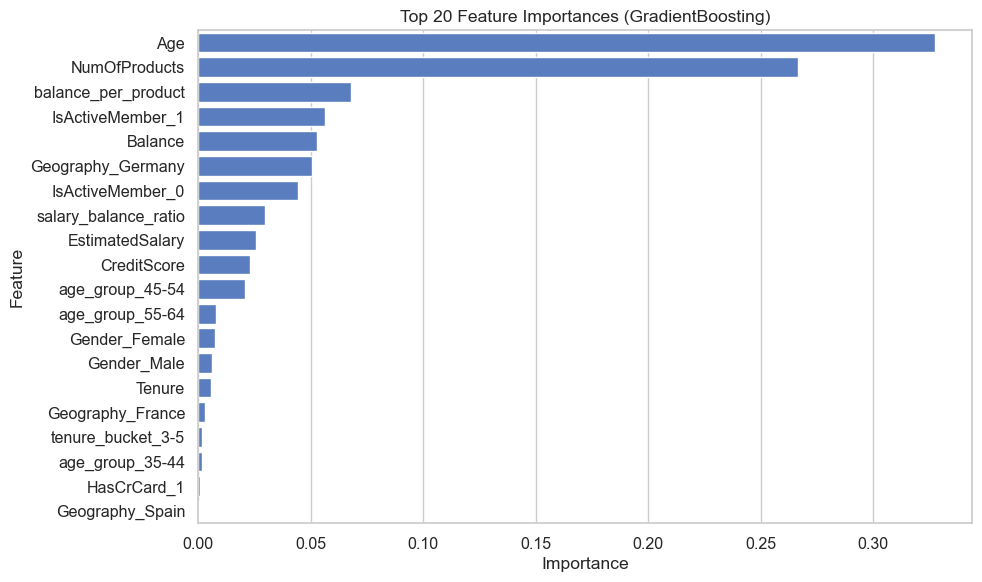

In [46]:
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):

    # Numeric feature names
    num_feats = numeric_features

    # One-hot encoded categorical feature names
    cat_feats = best_pipeline.named_steps['preprocessor'] \
        .named_transformers_['cat'] \
        .named_steps['onehot'] \
        .get_feature_names_out(categorical_features)

    # Combine feature names
    feature_names = list(num_feats) + list(cat_feats)

    # Feature importances
    importances = best_pipeline.named_steps['classifier'].feature_importances_

    # Create DataFrame
    fi = (
        pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })
        .sort_values('Importance', ascending=False)
        .head(20)
    )

    display(fi)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi, x='Importance', y='Feature')
    plt.title(f'Top 20 Feature Importances ({best_name})')
    plt.tight_layout()
    plt.show()

else:
    print(f"{best_name} does not provide feature_importances_.")

# Step 11. Save the best pipeline and preprocessing artifacts

In [47]:
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl


# Step 12. Example: Predict churn for a new customer

In [49]:
# --- New customer sample ---
sample = {
    'CreditScore': 650,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 40,
    'Tenure': 3,
    'Balance': 50000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = (
    sample_df['Balance'] /
    sample_df['NumOfProducts'].replace(0, np.nan)
)
sample_df['balance_per_product'] = sample_df['balance_per_product'].fillna(0)

sample_df['salary_balance_ratio'] = (
    sample_df['EstimatedSalary'] /
    sample_df['Balance'].replace(0, np.nan)
)
sample_df['salary_balance_ratio'] = (
    sample_df['salary_balance_ratio']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(sample_df['salary_balance_ratio'].median())
)

# Age group
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

sample_df['age_group'] = pd.cut(
    sample_df['Age'],
    bins=bins,
    labels=labels
)

# Tenure bucket
sample_df['tenure_bucket'] = pd.cut(
    sample_df['Tenure'],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=['0', '1-2', '3-5', '6-10', '10+']
)

# High balance flag (use training threshold)
balance_threshold = df_fe['Balance'].quantile(0.75)

sample_df['high_balance'] = (
    sample_df['Balance'] > balance_threshold
).astype(int)

# --- Predict ---
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0, 1]

print(f"Predicted Churn: {'Yes' if pred == 1 else 'No'}")
print(f"Probability of Churn: {prob:.2%}")

Predicted Churn: No
Probability of Churn: 3.03%
